In [21]:
import numpy as np #import library
from math import ceil
from scipy import stats
from scipy.integrate import quad
import pandas as pd
import matplotlib.pyplot as plt

limit=1000000 #limit under which we look for primes

primes_long = pd.read_csv("/Users/admin/Downloads/numbers.csv") #opens the list of all primes we are looking for
primes_long["value"] = pd.to_numeric(primes_long["value"]).astype(int) #converts numbers to integers
primes = primes_long[primes_long["value"] < limit]['value'].tolist() #cuts the list to the required limit

#finds polindromic primes in list of all primes
def find_pol_primes(primes):
    def is_palindrome(n):
        s = str(n)
        return s == s[::-1]
    
    return [p for p in primes if is_palindrome(p)]


pol_starts=find_pol_primes(primes) #finds the smallest twin in pair


def calculate_bin_size(pol_starts):
    min_counts_per_bin = 5
    sorted_pol = sorted(pol_starts)          # flat list, no unpacking
    bin_size = 0
    for i in range(len(sorted_pol) - min_counts_per_bin):
        current_gap = sorted_pol[i + min_counts_per_bin] - sorted_pol[i]
        if current_gap > bin_size:
            bin_size = current_gap
    return ceil(bin_size)



 
#sorts twin primes in bins
def count_primes_in_bins(pol_starts, num_bins, bin_size):
    bin_labels = []
    pol_prime_counts = []
    for i in range(num_bins):
        lo = 2 if i == 0 else i * bin_size
        hi = (i + 1) * bin_size
        pol_prime_counts.append(sum(1 for p in pol_starts if lo <= p <= hi))  # flat list, no unpacking
        bin_labels.append(f"{lo}-{hi}")
    return bin_labels, pol_prime_counts

#Hardy-Littlewood Conjecture
#sorts expected data in bins
def hardy_littlewood_conjecture(num_bins, bin_size):
  C2=0.6601618158
  expected_values=[]
  
  def integrand(t): #function inside integral
    return 1/(np.log(t)**2)
  
  
  for i in range (num_bins): #calculates the area under the curve for each bin
    lo=2 if i==0 else i*bin_size
    hi=(i+1)* bin_size
   
    area,_=quad(integrand,lo, hi)
    expected=2*C2*area
    expected_values.append(expected)
  return expected_values

#Goodnes of fit test
def chi_square_goodness_of_fit(observed_values, expected_values):
  statistic=0
  significance_level=0.05 
  for i in range (len(observed_values)): #loops through the prime number values
    statistic=statistic+(np.square(observed_values[i]-expected_values[i])/expected_values[i]) #chi squared statistic formula

  df=len(observed_values)-1
  p_value=stats.chi2.sf(statistic, df) #calculates p_value
  print(f"Chi-square statistic: {statistic:.4f}, p-value: {p_value:.4f}, df: {df}")
  if p_value>significance_level:
    print("Fail to reject H0")
  else:
    print("Reject H0")


bin_size=calculate_bin_size(pol_starts)
num_bins = ceil(limit/bin_size)
labels, observed_values = count_primes_in_bins(pol_starts, num_bins, bin_size)
for i in range(num_bins):
    print(f"Bin {labels[i]}: {observed_values[i]} twin primes")

expected_values=hardy_littlewood_conjecture(num_bins, bin_size)

print("H0= there is no significant difference between the distribution of twin primes and Hardy-Littlewood Conjecture ")
print("H1= there is significant difference between the distribution of twin primes and Hardy-Littlewood Conjecture ")
chi_square_goodness_of_fit(observed_values, expected_values)


Bin 2-32634: 55 twin primes
Bin 32634-65268: 15 twin primes
Bin 65268-97902: 41 twin primes
Bin 97902-130536: 2 twin primes
Bin 130536-163170: 0 twin primes
Bin 163170-195804: 0 twin primes
Bin 195804-228438: 0 twin primes
Bin 228438-261072: 0 twin primes
Bin 261072-293706: 0 twin primes
Bin 293706-326340: 0 twin primes
Bin 326340-358974: 0 twin primes
Bin 358974-391608: 0 twin primes
Bin 391608-424242: 0 twin primes
Bin 424242-456876: 0 twin primes
Bin 456876-489510: 0 twin primes
Bin 489510-522144: 0 twin primes
Bin 522144-554778: 0 twin primes
Bin 554778-587412: 0 twin primes
Bin 587412-620046: 0 twin primes
Bin 620046-652680: 0 twin primes
Bin 652680-685314: 0 twin primes
Bin 685314-717948: 0 twin primes
Bin 717948-750582: 0 twin primes
Bin 750582-783216: 0 twin primes
Bin 783216-815850: 0 twin primes
Bin 815850-848484: 0 twin primes
Bin 848484-881118: 0 twin primes
Bin 881118-913752: 0 twin primes
Bin 913752-946386: 0 twin primes
Bin 946386-979020: 0 twin primes
Bin 979020-1011654

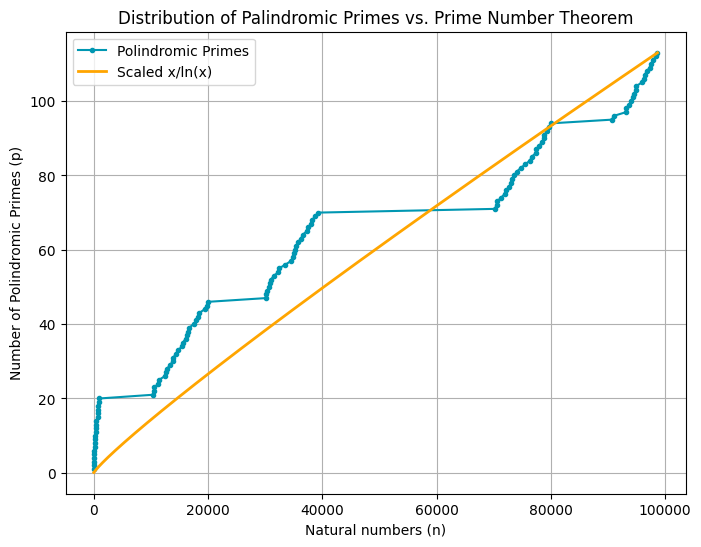

In [22]:
# Twin Prime Visualization
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad


def prime_number_theorem(x):
    return x/np.log(x)


#smooth x values from 2 to limit on a log scale
x_prime_number_theorem = np.logspace(np.log10(2), np.log10(max(xp)), 500)
y_prime_number_theorem = [prime_number_theorem(x)*scale for x in x_prime_number_theorem]


xp = pol_starts
yp= range(1, len(xp)+1)
scale = len(xp) / prime_number_theorem(max(xp))
# The circular prime list supplemented with R19 and R23 and the number of primes list (just the length of xp)
plt.figure(figsize=(8,6))
#plt.xscale('log')
#plt.yscale('log')
#plt.xticks([1e0,1e1,1e2,1e3,1e4,1e5,1e6,1e9,1e12,1e15,1e18,1e21])
plt.title('Distribution of Palindromic Primes vs. Prime Number Theorem')
plt.xlabel('Natural numbers (n)')
plt.ylabel('Number of Polindromic Primes (p)')
plt.plot(xp,yp, marker='.', label='Polindromic Primes', color='#0097b2')
plt.plot(x_prime_number_theorem, y_prime_number_theorem, label='Scaled x/ln(x)', color='orange', linewidth=2)
plt.legend()
plt.grid('0')
# Scaling customizing and adding extra information
plt.show()